# Laboratorio 6 : Filtros digitales

## Introducción
---
El procesamiento digital de señales biomédicas se ha consolidado como una herramienta esencial para mejorar la calidad de registros fisiológicos como la electromiografía (EMG) y la electrocardiografía (ECG). Estas señales, ampliamente utilizadas en el diagnóstico muscular y cardíaco, suelen estar contaminadas por ruido de línea, artefactos de movimiento o interferencias electromagnéticas, lo que dificulta su interpretación directa. Aplicar filtros digitales adecuados permite mejorar la relación señal/ruido (SNR) y preservar las características morfológicas relevantes para el análisis clínico[1,2].

## Ventajas de los filtros digitales frente a los analógicos
A diferencia de los filtros analógicos, los filtros digitales ofrecen ventajas como estabilidad, reproducibilidad y flexibilidad en su implementación. Mediante algoritmos computacionales, es posible ajustar parámetros con precisión, adaptarse a distintos tipos de señales y realizar análisis tanto en tiempo real como en post-procesamiento [3]. Además, plataformas como BITalino han facilitado la adquisición de señales biomédicas en entornos no controlados, lo que incrementa la necesidad de técnicas de filtrado robustas [4].

## Tipos de filtros digitales: FIR vs IIR
Los filtros digitales se dividen principalmente en dos categorías: FIR (Finite Impulse Response) e IIR (Infinite Impulse Response).
 - Los filtros FIR garantizan fase lineal y estabilidad absoluta, lo que los hace ideales para preservar la morfología de ondas ECG como P, QRS y T [1].
 - Los filtros IIR son más eficientes computacionalmente y permiten alcanzar respuestas similares a los filtros analógicos con menos coeficientes, aunque pueden introducir distorsión de fase si no se diseñan adecuadamente [3].

## Consideraciones de señales EMG y ECG
Cada tipo de señal posee un espectro de frecuencia característico. En el caso de la ECG, el rango útil suele estar entre 0.5 y 150 Hz, mientras que en la EMG se extiende de 10 a 500 Hz [1]. Por tanto, la elección del filtro debe considerar tanto la banda de interés como el tipo de ruido predominante.Por otro lado , investigaciones recientes han evaluado filtros como Butterworth, Chebyshev, Gaussian y convolucionales, no solo por su capacidad para atenuar interferencias, sino también por su impacto en el rendimiento de modelos de clasificación automática [3,5].

<div align="center">
  <img src="Imagenes/Filtros.png" alt="Diagrama de procesamiento digital de señales" width="600">
  <p><b>Figura 1.</b> Flujo de procesamiento digital de señales: la señal analógica pasa por un filtro antialiasing, luego se digitaliza mediante un ADC, es procesada digitalmente, convertida nuevamente a analógica con un DAC y finalmente suavizada con un filtro de reconstrucción.</p>
</div>

## Objetivos
---
- Aplicar diferentes filtros digitales a señales biomédicas de ECG y EMG adquiridas con BITalino, con el fin de reducir el ruido y resaltar las características relevantes de cada registro.
- Seleccionar y justificar el filtro más adecuado para cada caso (2 ECG y 2 EMG).

## Materiales
---

| Material | Foto | N° | Detalles |
|----------|------|:--:|----------|
| Kit BITalino (r)evolution | <p align="center"><img src="Imagenes/Bitalino.jpeg" alt="BITalino" width="350"/></p> | 1 | Placa de adquisición de bioseñales (ECG, EMG, EDA, etc.) con resolución ADC de 10 bits y frecuencia de muestreo configurable (hasta 1000 Hz). <br><br> **Incluye:** <br> • 1 cable de 2 hilos <br> • 1 cable de 3 hilos <br> • 5 electrodos <br> • 1 batería recargable LiPo 3.7 V <br> • 1 guía de inicio rápido <br> • 1 placa BITalino |
| Entorno de programación en Python | <p align="center"><img src="Imagenes/Python.png" alt="Python" width="350"/></p> | 1 | Lenguaje de programación utilizado para el procesamiento digital de señales.|
| Herramienta pyFDA | <p align="center"><img src="Imagenes/pyfda.png" alt="pyFDA" width="350"/></p> | 1 | Herramienta para el diseño, análisis y comparación de filtros digitales (FIR e IIR). Permite simular la respuesta en frecuencia y evaluar el desempeño de distintos filtros aplicados a señales biomédicas. |


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, freqz, filtfilt
import os

# Configuración para que los gráficos se muestren directamente en el notebook
%matplotlib inline

# Configuración de estilo para los gráficos para una mejor visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:

# Se definen las rutas relativas a los archivos de datos crudos.

BASE_PATH = '/content/Señales adquiridas'

# Verificamos que la ruta base exista para evitar errores posteriores
if not os.path.exists(BASE_PATH):
    print(f"ERROR: La ruta base '{BASE_PATH}' no fue encontrada.")
    print("Por favor, ajusta la variable BASE_PATH a la ubicación correcta de tus datos.")
else:
    print(f"Ruta base de datos encontrada en: '{BASE_PATH}'")

ARCHIVOS = {
    'EMG_Biceps': os.path.join(BASE_PATH, 'contraccion1.txt'),
    'EMG_Triceps': os.path.join(BASE_PATH, 'tricep_contraccion-09-03_12-57-54.txt'),
    'ECG_Reposo': os.path.join(BASE_PATH, 'Derivacion_1_reposo_2025-09-10_11-47-35.txt'),
    'ECG_PostEjercicio': os.path.join(BASE_PATH, 'derivación_1_actividad_fisica_2025-09-10_12-20-25.txt')
}

# 2. CONSTANTES DEL BITALINO

FS = 1000  # Frecuencia de muestreo en Hz
N_BITS = 10  # Resolución del ADC
VCC = 3.3  # Voltaje de operación en Volts

# Ganancias específicas para cada sensor [1]
G_EMG = 1009  # Ganancia del sensor EMG
G_ECG = 1100  # Ganancia del sensor ECG (valor estándar para BITalino)

print("\nConstantes y rutas definidas correctamente.")

Ruta base de datos encontrada en: '/content/Señales adquiridas'

Constantes y rutas definidas correctamente.


In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 4: Funciones de Carga y Conversión
# ------------------

def cargar_y_convertir_senal(file_path, tipo_sensor, fs=FS, n_bits=N_BITS, vcc=VCC):
    """
    Carga una señal cruda desde un archivo .txt de BITalino y la convierte de
    valores ADC a milivoltios (mV).

    Args:
        file_path (str): Ruta completa al archivo de datos.
        tipo_sensor (str): Tipo de sensor ('EMG' o 'ECG') para seleccionar la ganancia correcta.
        fs (int): Frecuencia de muestreo.
        n_bits (int): Resolución del ADC.
        vcc (float): Voltaje de operación.

    Returns:
        tuple: Una tupla conteniendo:
            - np.array: La señal convertida a mV.
            - np.array: El vector de tiempo correspondiente en segundos.
        O (None, None) si el archivo no se encuentra.
    """
    try:
        # Carga de los datos crudos. Los archivos de OpenSignals suelen tener
        # comentarios que inician con '#' y la señal de interés en la última columna.
        # 'delim_whitespace=True' maneja espacios o tabulaciones como separadores.
        datos_df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
        senal_adc = datos_df.iloc[:, -1].values
    except FileNotFoundError:
        print(f"ERROR: No se pudo encontrar el archivo en la ruta: {file_path}")
        return None, None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo {file_path}: {e}")
        return None, None

    # Seleccionar la ganancia adecuada según el tipo de sensor
    if tipo_sensor == 'EMG':
        ganancia = G_EMG
    elif tipo_sensor == 'ECG':
        ganancia = G_ECG
    else:
        print(f"ERROR: Tipo de sensor '{tipo_sensor}' no reconocido. Use 'EMG' o 'ECG'.")
        return None, None

    # Fórmula de conversión de ADC a mV [2]
    # EMG(mV) = [((ADC / 2^n) - 1/2) * VCC / G_sensor] * 1000
    senal_mv = (((senal_adc / (2**n_bits)) - 0.5) * vcc) / ganancia * 1000

    # Creación del vector de tiempo
    tiempo = np.arange(len(senal_mv)) / fs

    print(f"Señal '{os.path.basename(file_path)}' cargada y convertida a mV exitosamente.")
    return senal_mv, tiempo

# ---- Referencias ----
# [1] PLUX Wireless Biosignals. (s.f.). Electrocardiography (ECG) Sensor Datasheet.
# [2] De Luca, C. J. (2002). Surface Electromyography: Detection and Recording. Delsys Inc.

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 5: Carga de las Señales de Interés
# ------------------
# Utilizando la función definida en la celda 4, se cargan las cuatro señales
# y se almacenan en un diccionario para su fácil acceso.

SEÑALES_CRUDAS = {}

print("Iniciando la carga de señales...")

# Cargar señal EMG de Bíceps
senal_biceps, tiempo_biceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Biceps'], 'EMG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['EMG_Biceps'] = {'senal_mv': senal_biceps, 'tiempo': tiempo_biceps}

# Cargar señal EMG de Tríceps
senal_triceps, tiempo_triceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Triceps'], 'EMG')
if senal_triceps is not None:
    SEÑALES_CRUDAS['EMG_Triceps'] = {'senal_mv': senal_triceps, 'tiempo': tiempo_triceps}

# Cargar señal ECG en Reposo
senal_ecg_reposo, tiempo_ecg_reposo = cargar_y_convertir_senal(ARCHIVOS['ECG_Reposo'], 'ECG')
if senal_ecg_reposo is not None:
    SEÑALES_CRUDAS['ECG_Reposo'] = {'senal_mv': senal_ecg_reposo, 'tiempo': tiempo_ecg_reposo}

# Cargar señal ECG Post-Ejercicio
senal_ecg_post, tiempo_ecg_post = cargar_y_convertir_senal(ARCHIVOS['ECG_PostEjercicio'], 'ECG')
if senal_ecg_post is not None:
    SEÑALES_CRUDAS['ECG_PostEjercicio'] = {'senal_mv': senal_ecg_post, 'tiempo': tiempo_ecg_post}

print(f"\nCarga completa. Se cargaron {len(SEÑALES_CRUDAS)} de 4 señales.")

Iniciando la carga de señales...
Señal 'contraccion1.txt' cargada y convertida a mV exitosamente.
Señal 'tricep_contraccion-09-03_12-57-54.txt' cargada y convertida a mV exitosamente.


/tmp/ipython-input-3046945716.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  datos_df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
/tmp/ipython-input-3046945716.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  datos_df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
/tmp/ipython-input-3046945716.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  datos_df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


Señal 'Derivacion_1_reposo_2025-09-10_11-47-35.txt' cargada y convertida a mV exitosamente.
Señal 'derivación_1_actividad_fisica_2025-09-10_12-20-25.txt' cargada y convertida a mV exitosamente.

Carga completa. Se cargaron 4 de 4 señales.


/tmp/ipython-input-3046945716.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  datos_df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


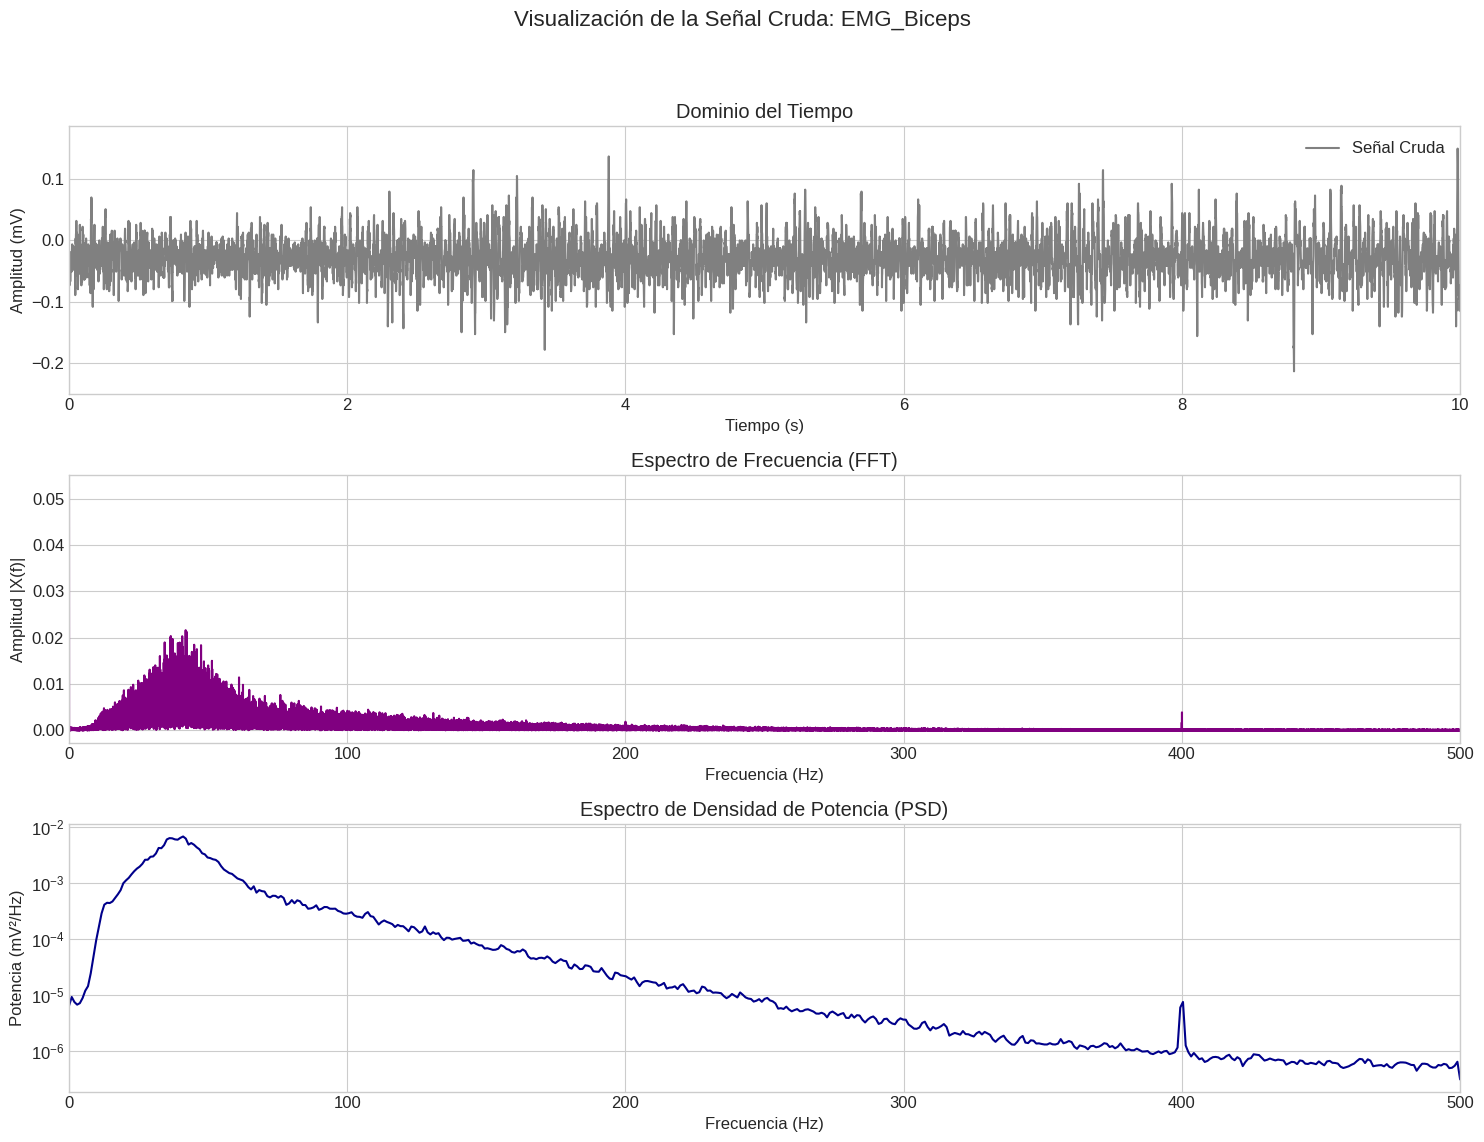

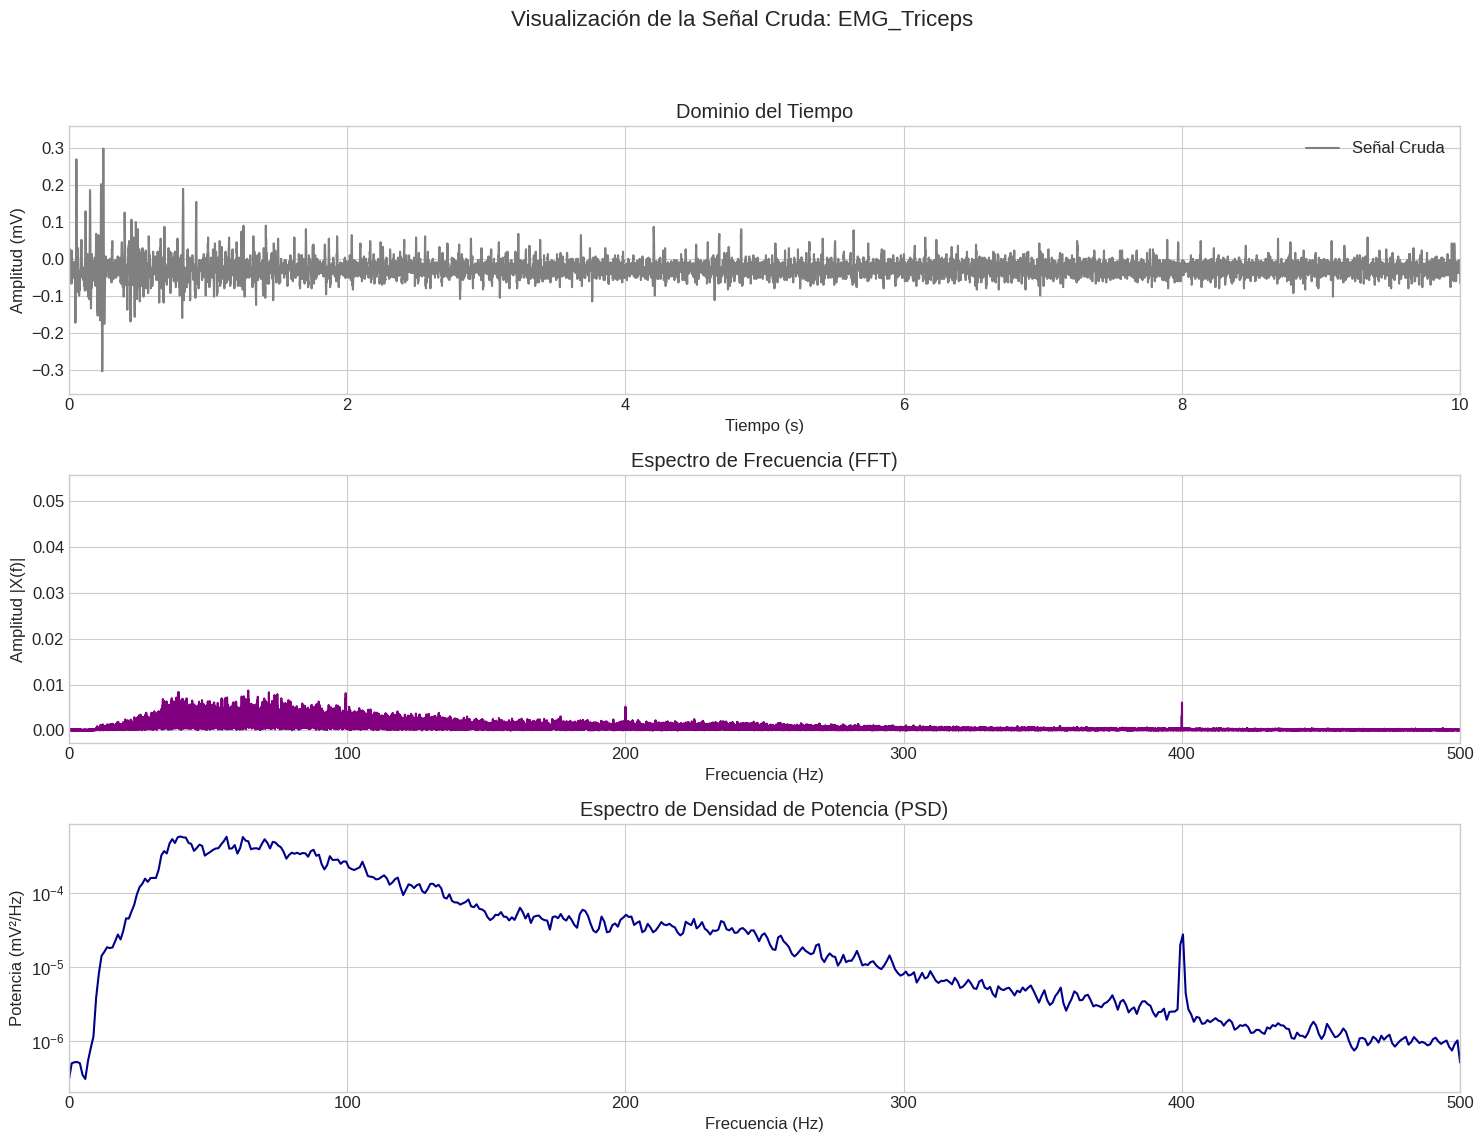

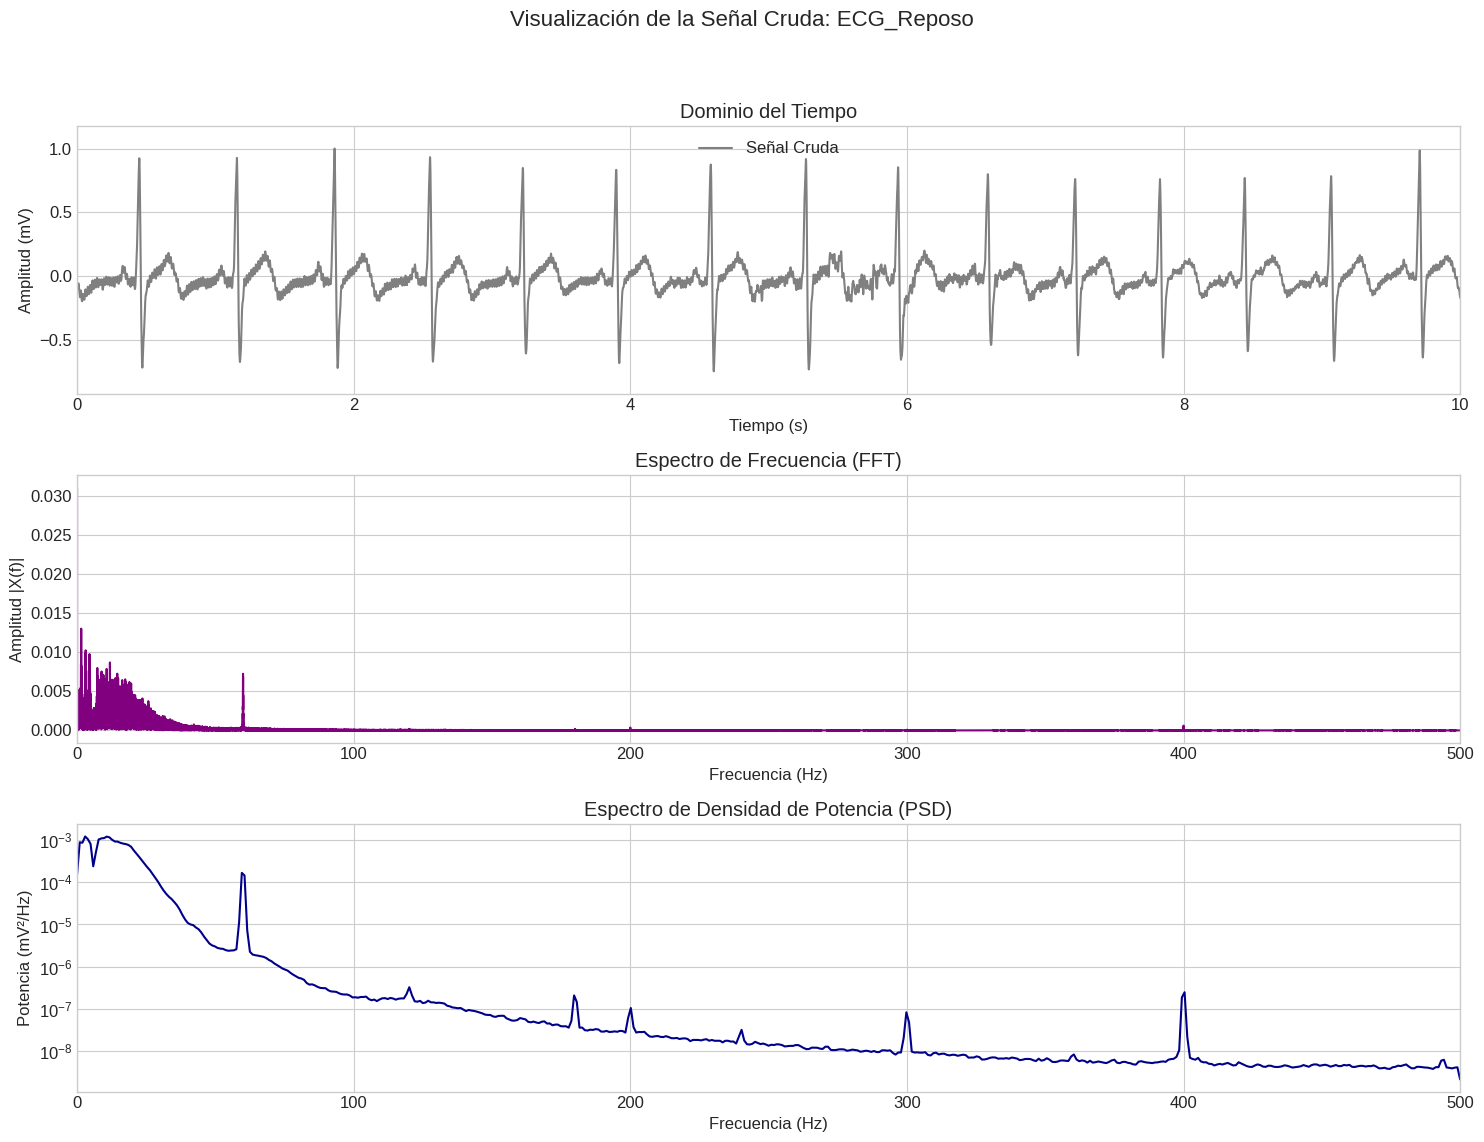

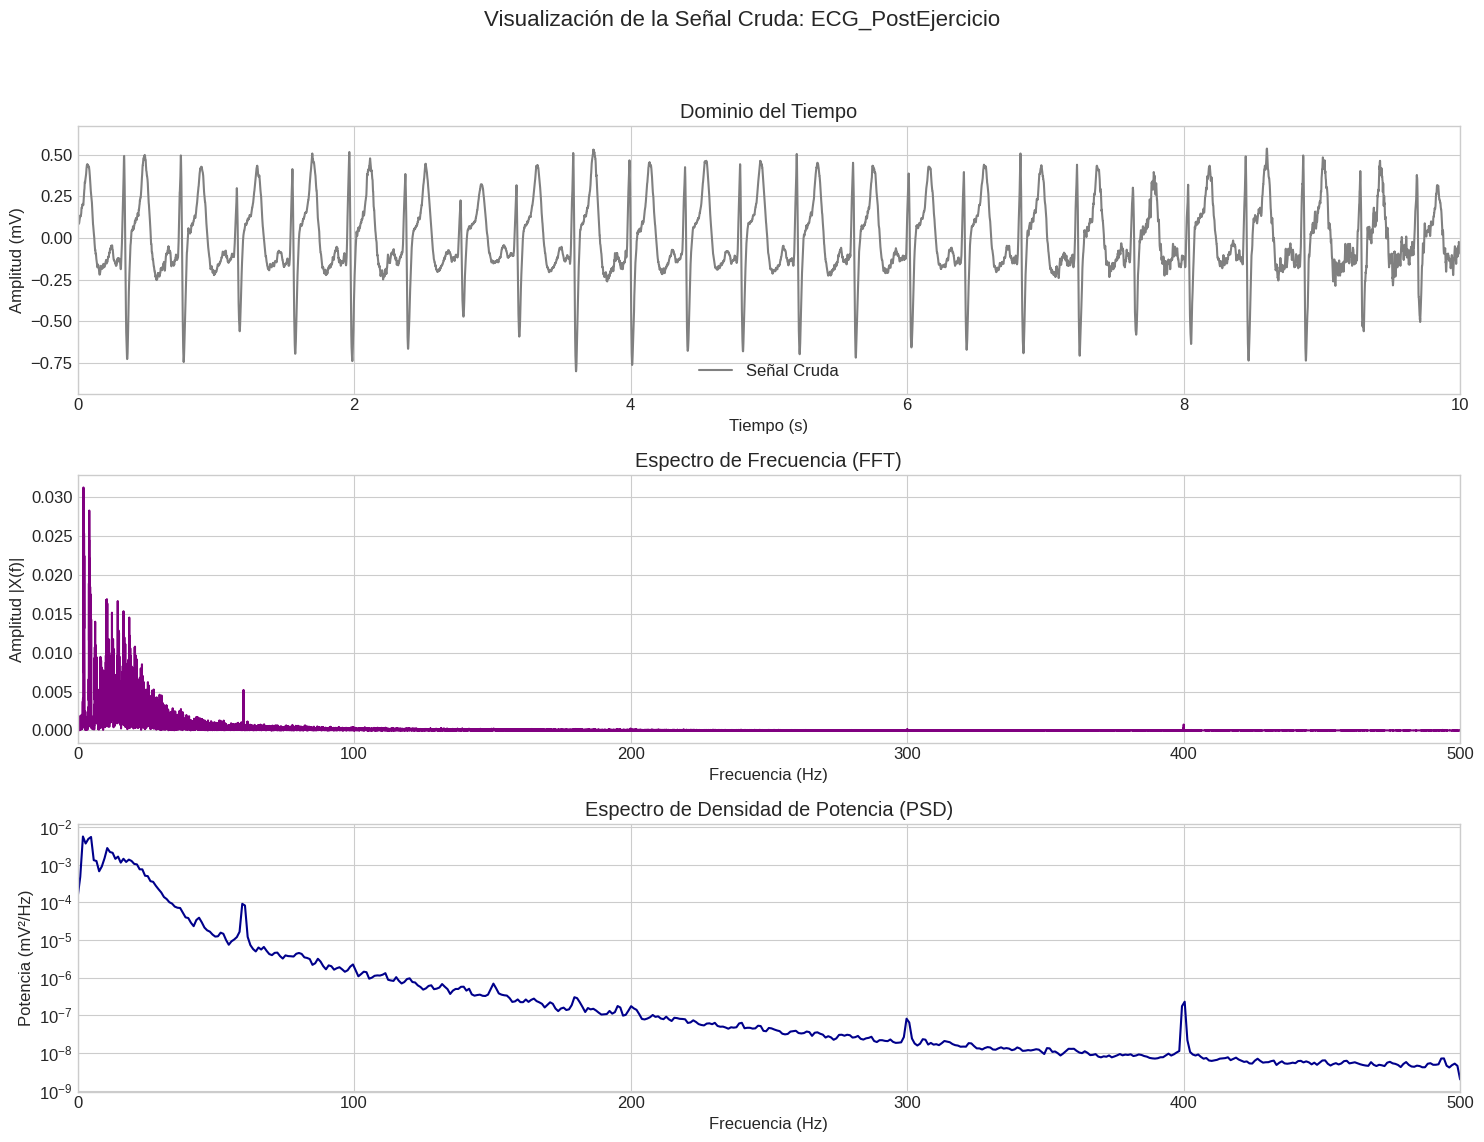


Visualización de gráficos de señales crudas completada.


In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 6: Visualización de Señales Crudas (con Eje Y Dinámico)
# ------------------

if not SEÑALES_CRUDAS:
    print("No hay señales cargadas para visualizar. Revisa las celdas anteriores.")
else:
    for nombre, datos in SEÑALES_CRUDAS.items():
        # Extraer datos para facilitar el acceso
        senal = datos['senal_mv']
        tiempo = datos['tiempo']
        N = len(senal) # Número de muestras

        # Crear figura con tres subplots
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
        fig.suptitle(f'Visualización de la Señal Cruda: {nombre}', fontsize=16)

        # --- Subplot 1: Dominio del Tiempo ---
        ax1.plot(tiempo, senal, color='gray', label='Señal Cruda')
        ax1.set_title('Dominio del Tiempo')
        ax1.set_xlabel('Tiempo (s)')
        ax1.set_ylabel('Amplitud (mV)')
        ax1.legend()
        ax1.grid(True)

        # Límite de tiempo para la visualización
        limite_tiempo = 10.0
        if tiempo[-1] > limite_tiempo:
            ax1.set_xlim(0, limite_tiempo)

        # --- MODIFICACIÓN: Ajuste dinámico de los límites del eje Y ---
        # 1. Seleccionar solo la porción de la señal que se está visualizando
        muestras_visibles = int(limite_tiempo * FS) if tiempo[-1] > limite_tiempo else N
        segmento_visible = senal[:muestras_visibles]

        # 2. Calcular el mínimo y máximo de ese segmento
        min_y = np.min(segmento_visible)
        max_y = np.max(segmento_visible)

        # 3. Añadir un margen (ej. 10%) para que no se vea tan ajustado
        margen = (max_y - min_y) * 0.1

        # 4. Establecer los nuevos límites del eje Y
        ax1.set_ylim(min_y - margen, max_y + margen)
        # --- FIN DE LA MODIFICACIÓN ---

        # --- Subplot 2: Espectro de Frecuencia (FFT) ---
        yf = np.fft.fft(senal)
        xf = np.fft.fftfreq(N, 1 / FS)
        fft_magnitude = 2.0/N * np.abs(yf[:N//2])

        ax2.plot(xf[:N//2], fft_magnitude, color='purple')
        ax2.set_title('Espectro de Frecuencia (FFT)')
        ax2.set_xlabel('Frecuencia (Hz)')
        ax2.set_ylabel('Amplitud |X(f)|')
        ax2.grid(True)
        ax2.set_xlim(0, FS / 2)

        # --- Subplot 3: Espectro de Densidad de Potencia (PSD) ---
        frecuencias, psd = welch(senal, fs=FS, nperseg=1024)
        ax3.semilogy(frecuencias, psd, color='darkblue')
        ax3.set_title('Espectro de Densidad de Potencia (PSD)')
        ax3.set_xlabel('Frecuencia (Hz)')
        ax3.set_ylabel('Potencia (mV²/Hz)')
        ax3.grid(True)
        ax3.set_xlim(0, FS / 2)

        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

print("\nVisualización de gráficos de señales crudas completada.")

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 9: Carga de los Coeficientes de Filtros EMG desde archivos CSV
# ------------------
# En esta celda, se cargan los coeficientes de los 4 filtros diseñados en pyfda.
# La función de carga está preparada para manejar tanto filtros FIR (una columna,
# solo coeficientes 'b') como filtros IIR (dos columnas, 'b' y 'a').

# Define la ruta a la carpeta que contiene los archivos de coeficientes
path_filtros = '/content/Filtros_EMG'

# Nombres de los archivos .csv con los coeficientes
# Asegúrate de que estos nombres coincidan con los archivos que guardaste.
nombres_archivos_filtros = {
    'FIR_EQ': 'FIR_Equiripple_pasa_banda_EMG.csv',     # Filtro 1 (Pasa-Banda FIR)
    'FIR_HA': 'FIR_Haming_pasa_banda_EMG.csv',     # Filtro 2 (Pasa-Banda IIR)
    'IIR_BT': 'IIR_Butter_pasa_banda_EMG.csv',     # Filtro 3 (Pasa-Bajo FIR)
    'IIR_EL': 'IIR_Eliptico_pasa_banda_EMG.csv'      # Filtro 4 (Pasa-Alto FIR)
}

def cargar_coeficientes_csv(filepath):
    """
    Carga los coeficientes de un filtro desde un archivo CSV.
    Detecta automáticamente si es un filtro FIR o IIR basado en el número de columnas.
    """
    try:
        # Usamos np.loadtxt, que es eficiente para archivos puramente numéricos como los CSV de pyfda.
        # No se espera un encabezado (header).
        coefs = np.loadtxt(filepath, delimiter=',')

        # --- Lógica para diferenciar FIR de IIR ---
        # Si el array cargado tiene solo una dimensión (es una lista de números),
        # significa que el archivo tenía una sola columna. Esto corresponde a un filtro FIR.
        if coefs.ndim == 1:
            b = coefs
            # Para un filtro FIR, el denominador 'a' es simplemente el número 1.
            a = np.array([1.0])
            tipo = "FIR"
        # Si el array tiene dos dimensiones, tenía dos columnas (b y a). Es un IIR.
        else:
            b = coefs[:, 0]  # La primera columna son los coeficientes 'b'
            a = coefs[:, 1]  # La segunda columna son los coeficientes 'a'
            tipo = "IIR"

        return b, a, tipo
    except FileNotFoundError:
        print(f"  -> ERROR: No se encontró el archivo: {os.path.basename(filepath)}")
        return None, None, None
    except Exception as e:
        print(f"  -> ERROR al leer el archivo {os.path.basename(filepath)}: {e}")
        return None, None, None

# Diccionario para almacenar los coeficientes cargados
FILTROS_EMG = {}

print(f"Cargando coeficientes desde la carpeta '{path_filtros}'...")
for nombre, filename in nombres_archivos_filtros.items():
    filepath = os.path.join(path_filtros, filename)
    b, a, tipo_filtro = cargar_coeficientes_csv(filepath)

    if b is not None:
        FILTROS_EMG[nombre] = {'b': b, 'a': a}
        print(f"  - Filtro '{nombre}' (tipo {tipo_filtro}) cargado exitosamente.")

if len(FILTROS_EMG) == 4:
    print("\n[ÉXITO] Los 4 filtros EMG se cargaron correctamente.")
else:
    print("\n[ADVERTENCIA] No se pudieron cargar todos los filtros. Revisa los nombres de archivo en la celda.")

Cargando coeficientes desde la carpeta '/content/Filtros_EMG'...
  - Filtro 'FIR_EQ' (tipo FIR) cargado exitosamente.
  - Filtro 'FIR_HA' (tipo FIR) cargado exitosamente.
  - Filtro 'IIR_BT' (tipo IIR) cargado exitosamente.
  - Filtro 'IIR_EL' (tipo IIR) cargado exitosamente.

[ÉXITO] Los 4 filtros EMG se cargaron correctamente.


Generando gráficos comparativos para las señales EMG...

--- Procesando Señal: EMG_Biceps ---


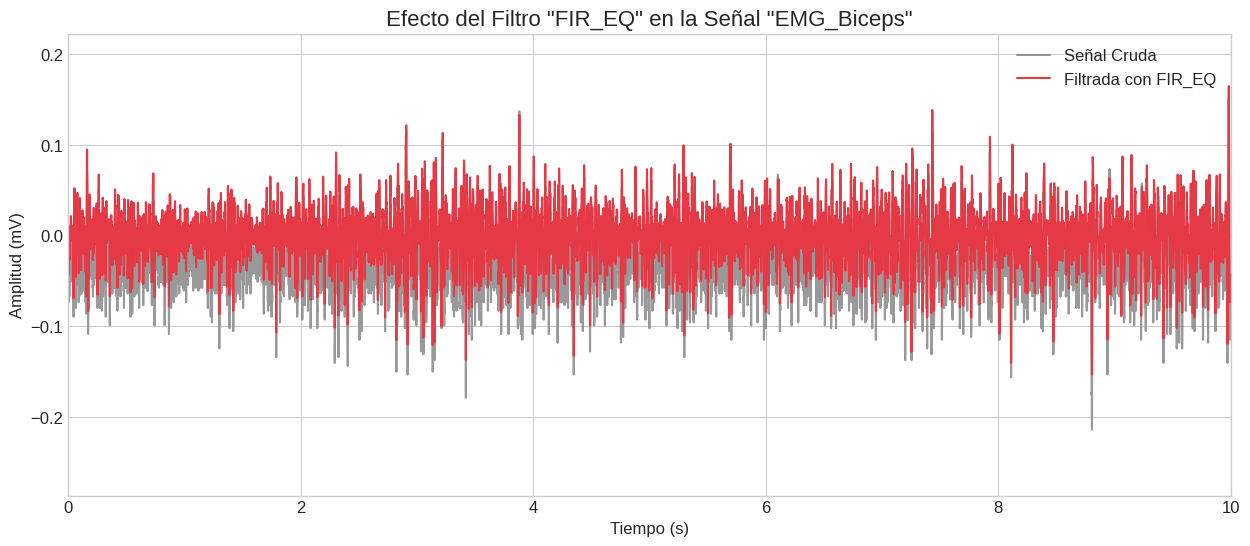

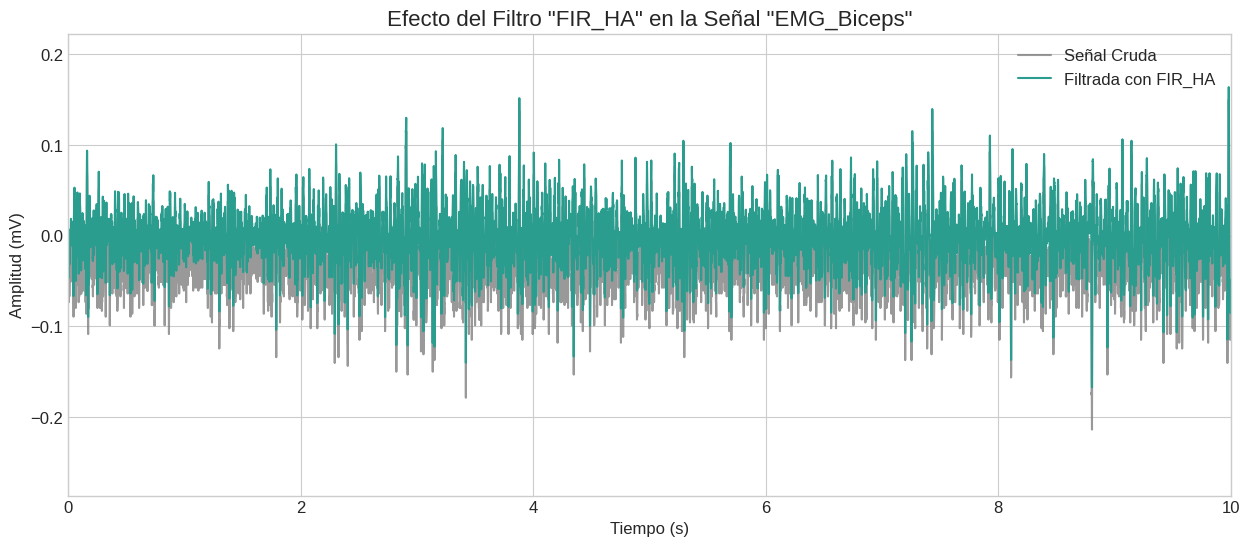

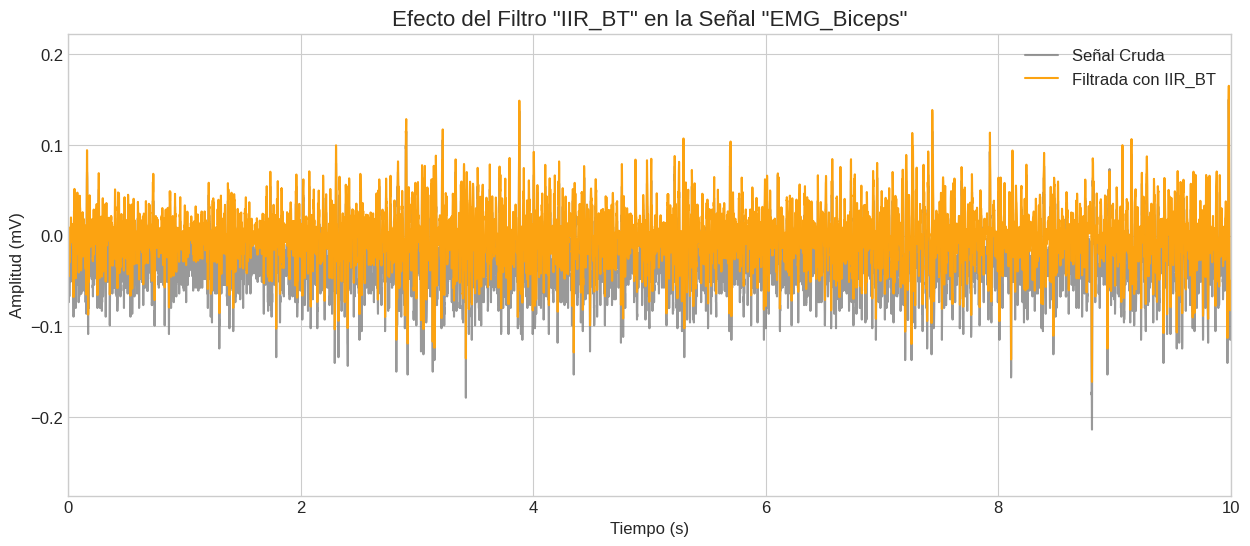

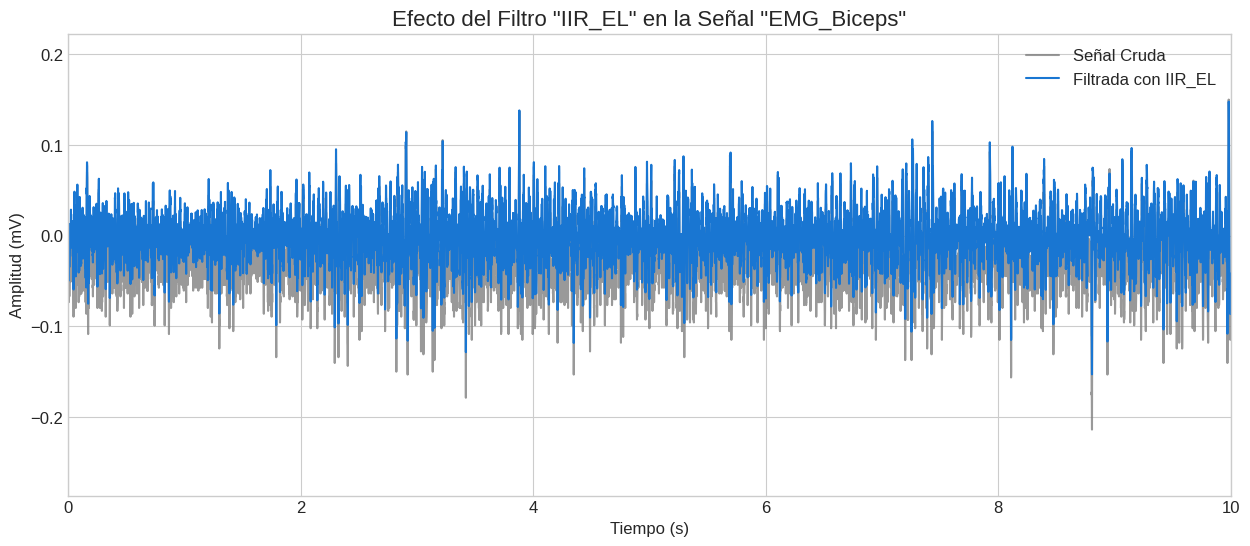


--- Procesando Señal: EMG_Triceps ---


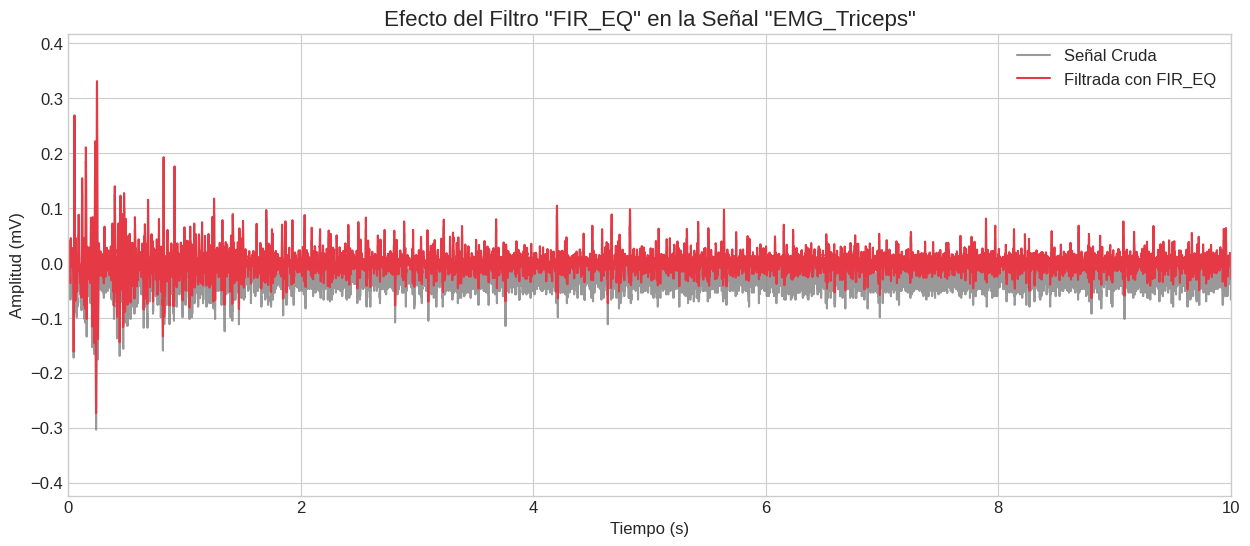

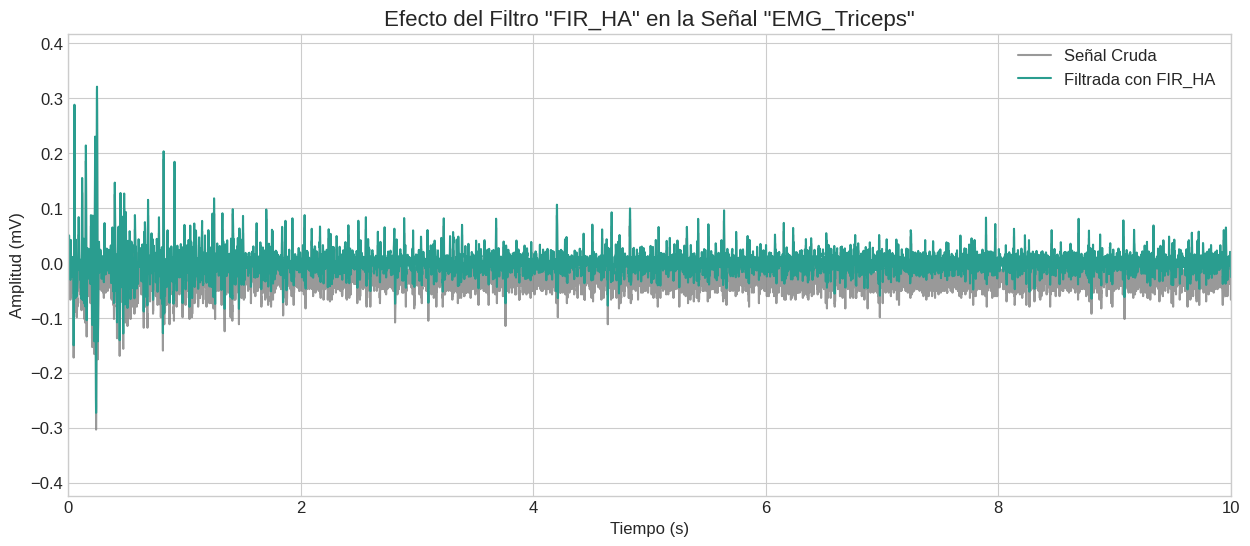

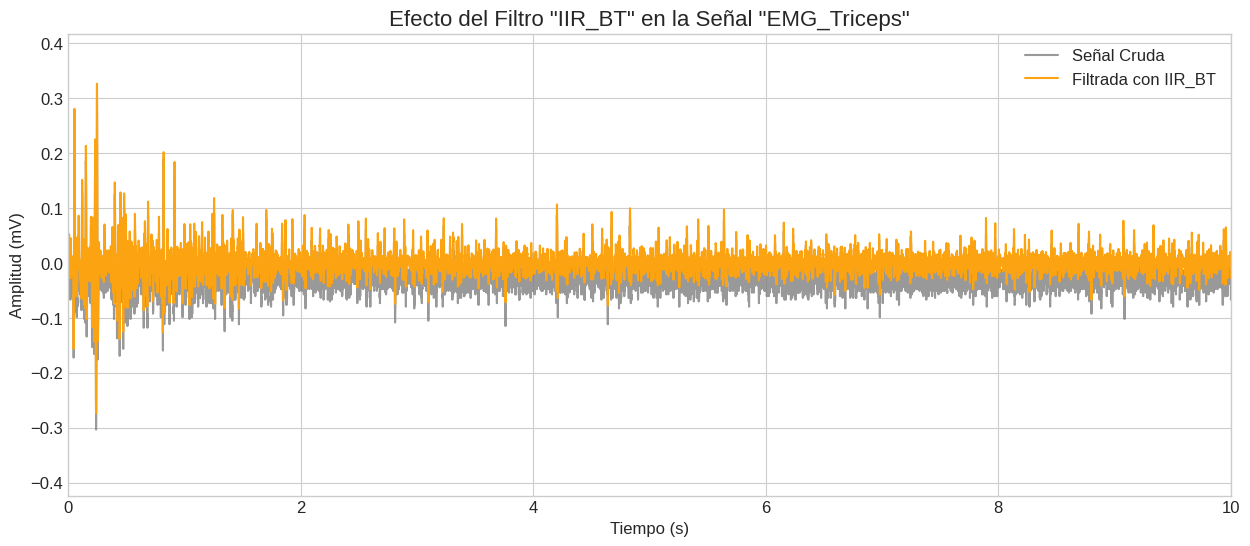

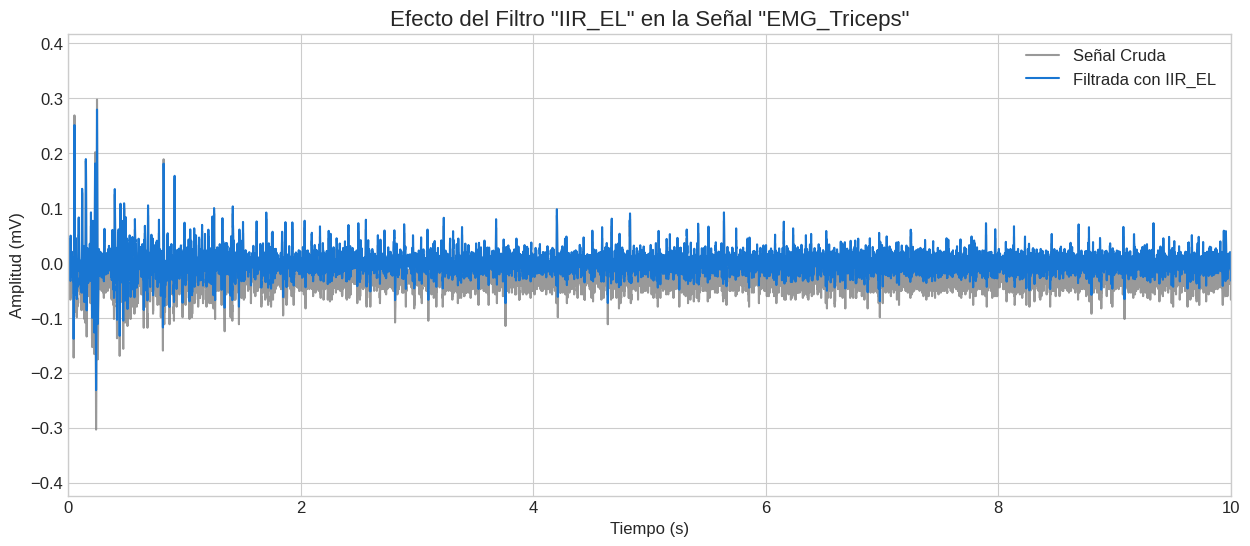

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 10: Comparación Visual de los Filtros Aplicados a Señales EMG
# ------------------
# Se itera sobre cada señal EMG y cada filtro cargado. Para cada combinación,
# se aplica el filtro y se genera un gráfico que superpone la señal cruda
# con la señal filtrada para una comparación visual directa.

# Lista de colores llamativos para las señales filtradas
colores_filtros = ['#e63946', '#2a9d8f', '#fca311', '#1976d2']

# Nombres de las señales EMG que queremos procesar
senales_a_filtrar = ['EMG_Biceps', 'EMG_Triceps']

print("Generando gráficos comparativos para las señales EMG...")

for nombre_senal in senales_a_filtrar:
    print(f"\n--- Procesando Señal: {nombre_senal} ---")

    # Extraer la señal cruda y el tiempo
    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']

    # Iterar sobre cada filtro
    for i, (nombre_filtro, coefs) in enumerate(FILTROS_EMG.items()):
        b = coefs['b']
        a = coefs['a']

        # Aplicar el filtro. Usamos filtfilt para un filtrado de fase cero,
        # lo cual es crucial para no desfasar la señal.
        senal_filtrada = filtfilt(b, a, senal_cruda)

        # Crear el gráfico
        plt.figure(figsize=(15, 6))
        plt.plot(tiempo, senal_cruda, color='gray', alpha=0.8, label='Señal Cruda')
        plt.plot(tiempo, senal_filtrada, color=colores_filtros[i], linewidth=1.5, label=f'Filtrada con {nombre_filtro}')

        # Configuración del gráfico
        plt.title(f'Efecto del Filtro "{nombre_filtro}" en la Señal "{nombre_senal}"', fontsize=16)
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (mV)')
        plt.legend()
        plt.grid(True)

        # Ajustar límites para una mejor visualización (zoom en los primeros segundos)
        limite_tiempo = 10.0
        if tiempo[-1] > limite_tiempo:
            plt.xlim(0, limite_tiempo)

        muestras_visibles = int(limite_tiempo * FS)
        segmento_visible = senal_cruda[:muestras_visibles]
        min_y, max_y = np.min(segmento_visible), np.max(segmento_visible)
        margen = (max_y - min_y) * 0.2
        plt.ylim(min_y - margen, max_y + margen)

        plt.show()

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 11: Evaluación Cuantitativa - Cálculo de SNR y Tabla Comparativa
# ------------------
# Se define una función para calcular el SNR en señales EMG, donde la 'señal'
# es un período de contracción y el 'ruido' es un período de reposo.
# Luego, se aplica a todas las combinaciones y se presenta en un DataFrame.

def calcular_snr_emg(senal, tiempo, t_signal, t_noise):
    """
    Calcula la Relación Señal-Ruido (SNR) para una señal EMG.

    Args:
        senal (np.array): La señal (ya filtrada).
        tiempo (np.array): El vector de tiempo.
        t_signal (tuple): Tupla (inicio, fin) en segundos del período de contracción.
        t_noise (tuple): Tupla (inicio, fin) en segundos del período de reposo.

    Returns:
        float: El valor de SNR en decibelios (dB).
    """
    # Encontrar los índices correspondientes a los períodos de tiempo
    idx_signal = np.where((tiempo >= t_signal[0]) & (tiempo < t_signal[1]))[0]
    idx_noise = np.where((tiempo >= t_noise[0]) & (tiempo < t_noise[1]))[0]

    if len(idx_signal) == 0 or len(idx_noise) == 0:
        return np.nan # No se pueden calcular si los segmentos están vacíos

    # Extraer los segmentos de la señal
    segmento_signal = senal[idx_signal]
    segmento_noise = senal[idx_noise]

    # Calcular la potencia como la varianza (o el poder medio cuadrático)
    potencia_signal = np.var(segmento_signal)
    potencia_noise = np.var(segmento_noise)

    if potencia_noise == 0:
        return np.inf # Evitar división por cero

    # Calcular SNR en dB
    snr_db = 10 * np.log10(potencia_signal / potencia_noise)

    return snr_db

# --- Definición de los Períodos de Señal y Ruido ---
# Estos valores se estiman observando los protocolos de adquisición de los labs anteriores.
# Deben ser ajustados si los resultados no son lógicos.
periodos = {
    'EMG_Biceps': {'signal': (15, 25), 'noise': (0, 10)},
    'EMG_Triceps': {'signal': (15, 25), 'noise': (0, 10)}
}

# --- Cálculo y Almacenamiento de Resultados ---
resultados_snr = []

print("Calculando SNR para cada filtro y señal EMG...")
for nombre_senal in senales_a_filtrar:
    fila_actual = {'Señal': nombre_senal}
    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']

    # Obtener los períodos para esta señal
    t_signal = periodos[nombre_senal]['signal']
    t_noise = periodos[nombre_senal]['noise']

    for nombre_filtro, coefs in FILTROS_EMG.items():
        senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_cruda)
        snr = calcular_snr_emg(senal_filtrada, tiempo, t_signal, t_noise)
        fila_actual[f'SNR {nombre_filtro}'] = snr

    resultados_snr.append(fila_actual)

# --- Presentación de la Tabla ---
# Convertir la lista de resultados a un DataFrame de Pandas para una bonita visualización
df_snr_emg = pd.DataFrame(resultados_snr)

print("\nTabla Comparativa de SNR para Señales EMG (en dB):")
display(df_snr_emg.round(2))

Calculando SNR para cada filtro y señal EMG...

Tabla Comparativa de SNR para Señales EMG (en dB):


,Señal,SNR FIR_EQ,SNR FIR_HA,SNR IIR_BT,SNR IIR_EL
0,EMG_Biceps,24.47,24.28,24.31,23.98
1,EMG_Triceps,19.44,19.38,19.38,19.25


In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 13: Carga de los Coeficientes de Filtros ECG
# ------------------
# Replicando el proceso de la Fase 2, se cargan los coeficientes para
# los filtros diseñados específicamente para la señal ECG.

# Define la ruta a la carpeta que contiene los archivos de coeficientes para ECG
path_filtros_ecg = '/content/Filtros_EEG'

# !! IMPORTANTE !!
# Reemplaza los siguientes nombres de archivo con los nombres EXACTOS
# de los archivos .csv que has exportado desde pyfda para tus filtros ECG.
nombres_archivos_filtros_ecg = {
    'FIR_BL': 'FIR_Blackman_pasa_bajas_EEG.csv',
    'FIR_HM': 'FIR_Hamming_pasa_bajas_EEG.csv',
    'IIR_Notch': 'IIR_Butter_rechaza_banda_EEG.csv',
    'IIR_PB': 'IIR_Eliptico_pasa_baja_EEG.csv'
}

# Diccionario para almacenar los coeficientes cargados
FILTROS_ECG = {}

print(f"Cargando coeficientes desde la carpeta '{path_filtros_ecg}'...")
# Usamos la misma función 'cargar_coeficientes_csv' que definimos antes.
for nombre, filename in nombres_archivos_filtros_ecg.items():
    filepath = os.path.join(path_filtros_ecg, filename)
    b, a, tipo_filtro = cargar_coeficientes_csv(filepath)

    if b is not None:
        FILTROS_ECG[nombre] = {'b': b, 'a': a}
        print(f"  - Filtro ECG '{nombre}' (tipo {tipo_filtro}) cargado exitosamente.")

if len(FILTROS_ECG) == 4:
    print("\n[ÉXITO] Los 4 filtros ECG se cargaron correctamente.")
else:
    print("\n[ADVERTENCIA] No se pudieron cargar todos los filtros. Revisa la ruta y los nombres de archivo.")

Cargando coeficientes desde la carpeta '/content/Filtros_EEG'...
  - Filtro ECG 'FIR_BL' (tipo FIR) cargado exitosamente.
  - Filtro ECG 'FIR_HM' (tipo FIR) cargado exitosamente.
  - Filtro ECG 'IIR_Notch' (tipo IIR) cargado exitosamente.
  - Filtro ECG 'IIR_PB' (tipo IIR) cargado exitosamente.

[ÉXITO] Los 4 filtros ECG se cargaron correctamente.


Generando gráficos comparativos para las señales ECG...

--- Procesando Señal: ECG_Reposo ---


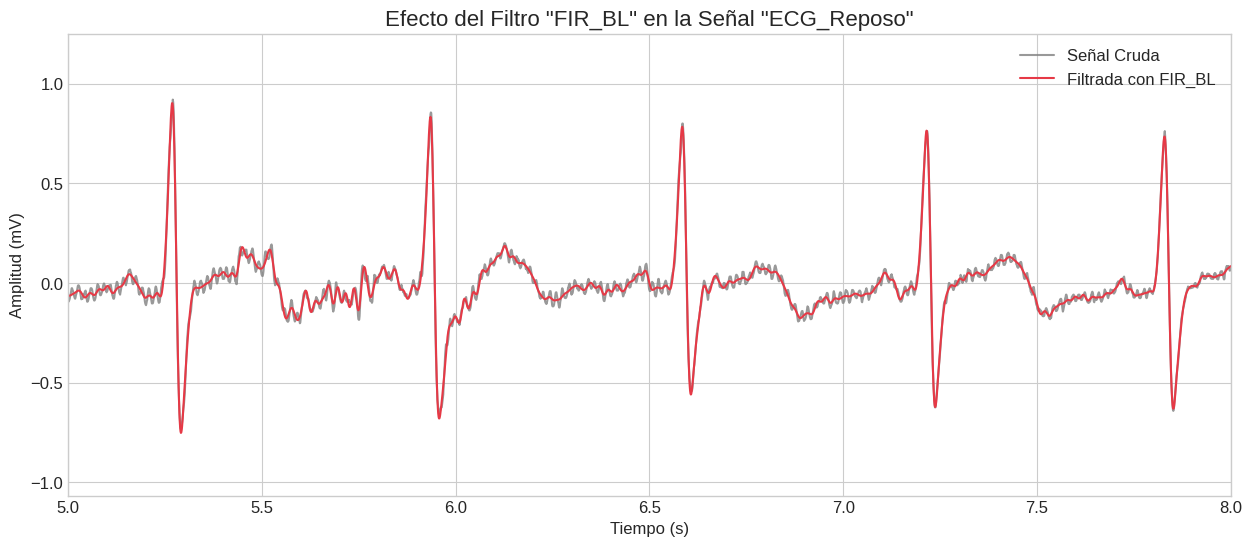

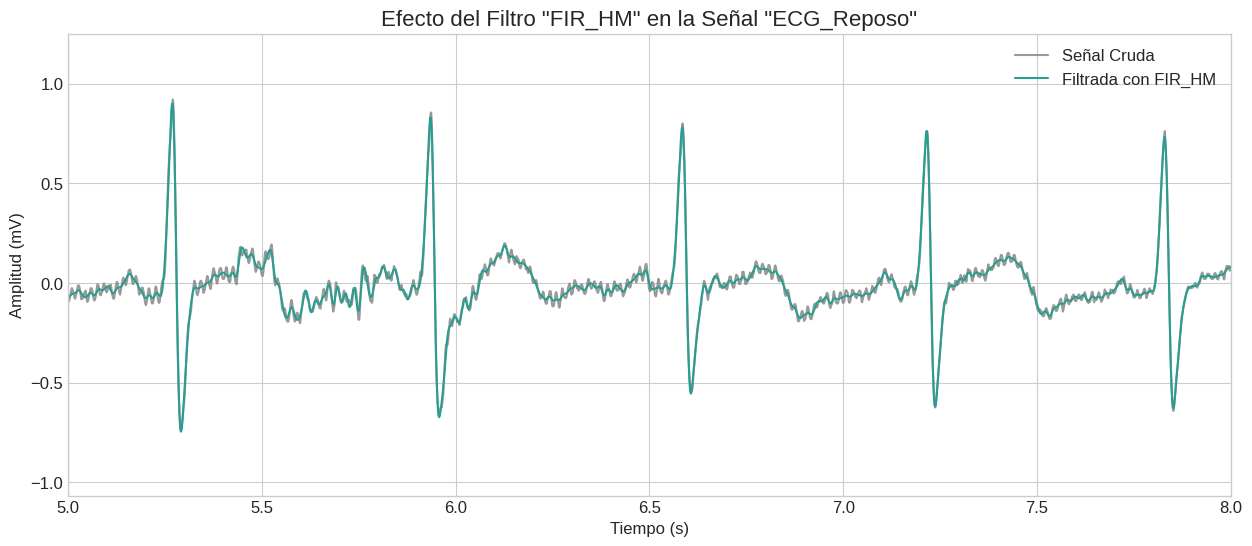

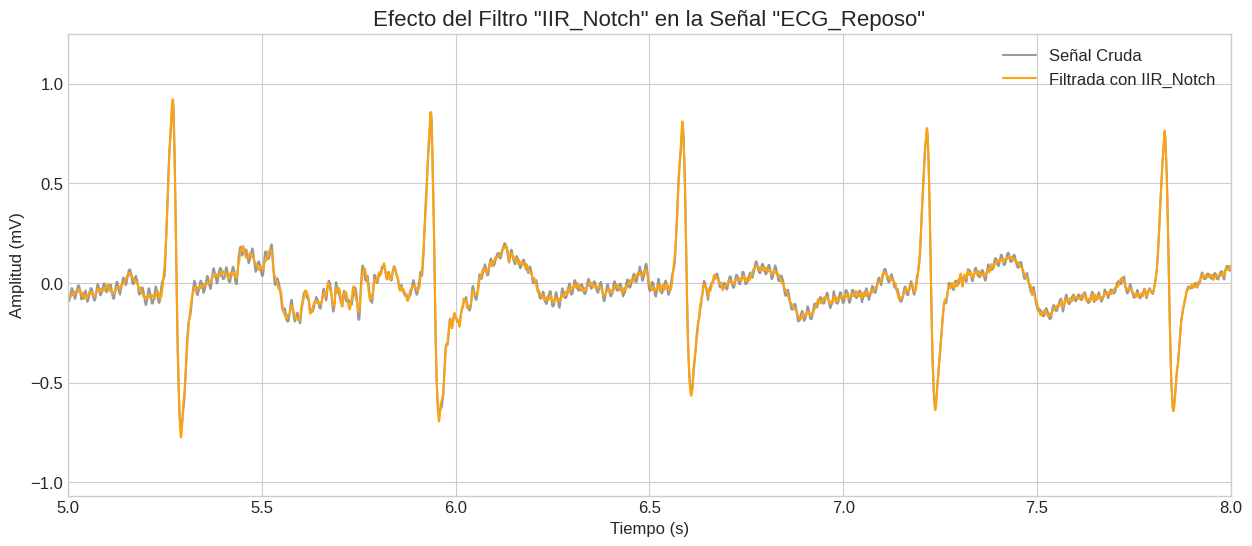

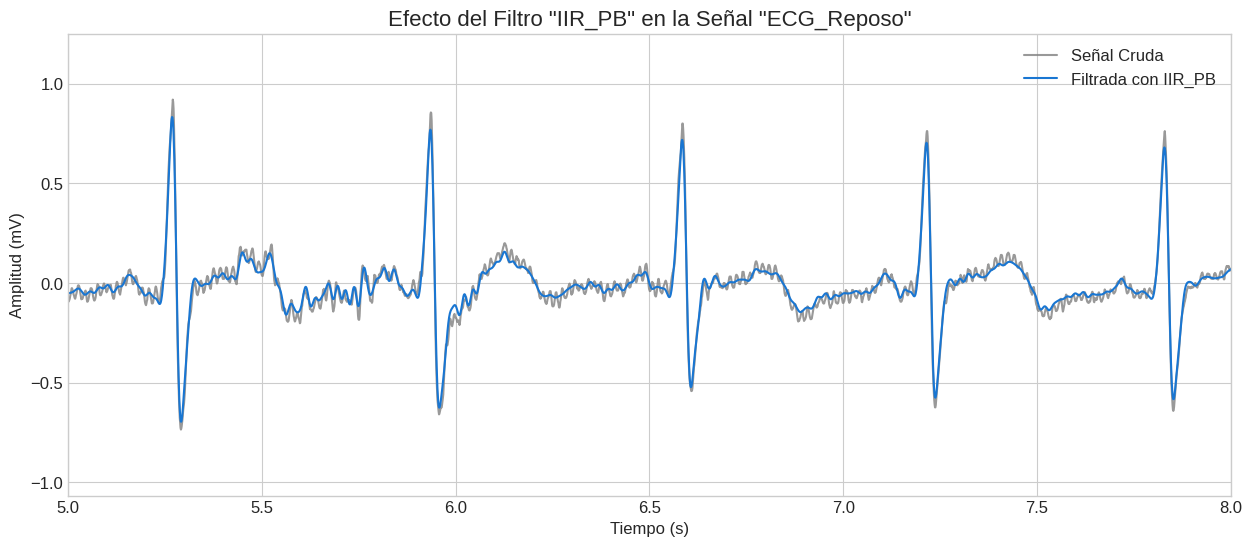


--- Procesando Señal: ECG_PostEjercicio ---


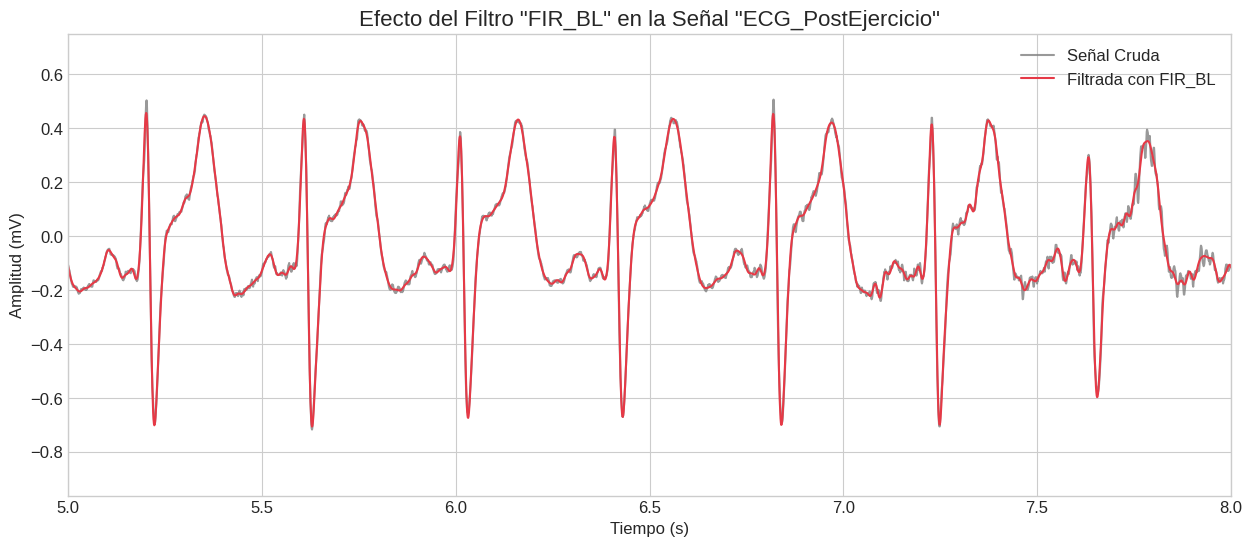

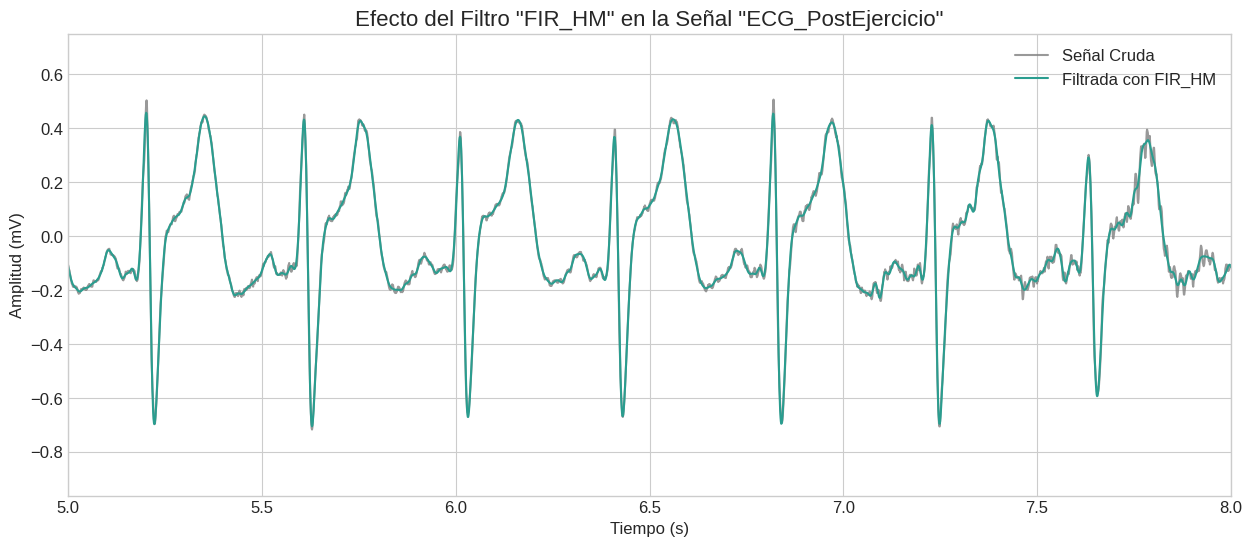

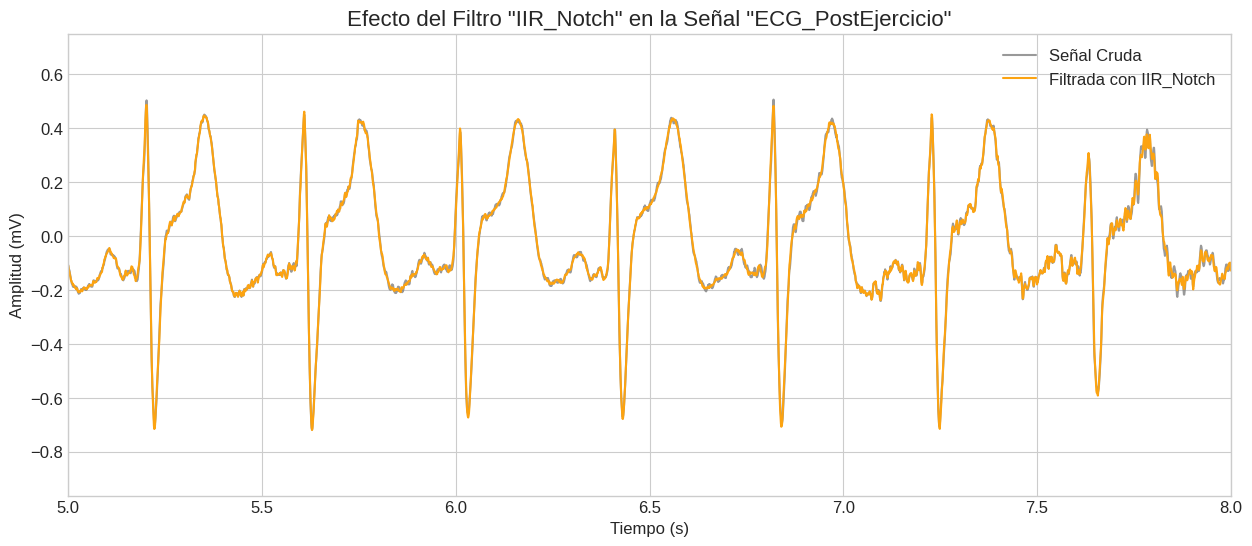

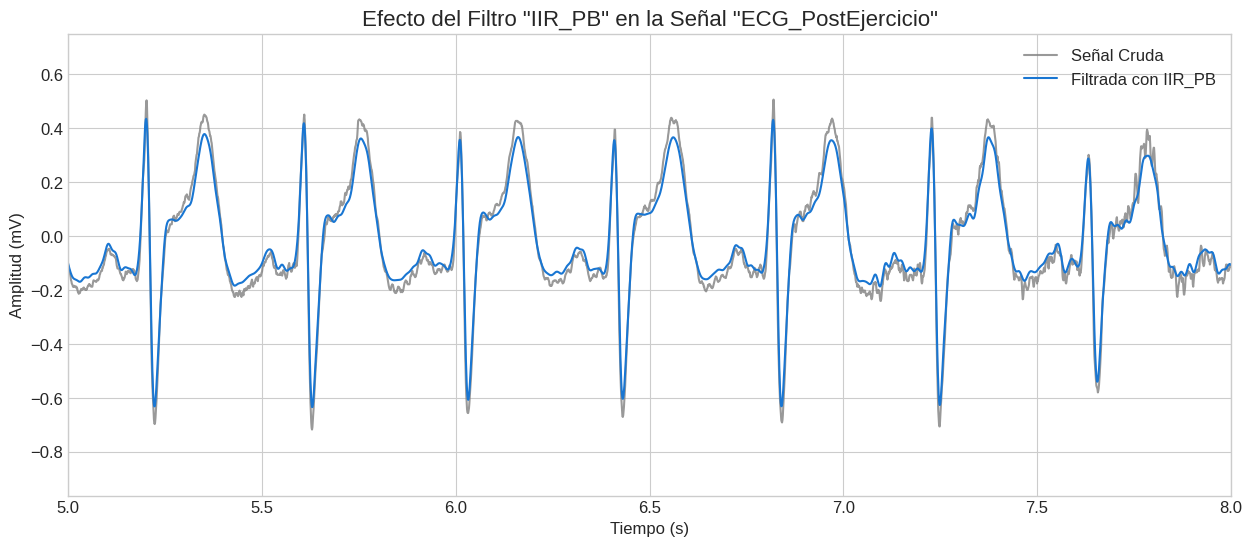

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 14: Comparación Visual de los Filtros Aplicados a Señales ECG
# ------------------
# Se aplica cada filtro a las dos señales ECG (reposo y post-ejercicio).
# Los gráficos se centran en un segmento corto para poder apreciar el
# impacto del filtrado en la morfología del latido cardíaco.

# Nombres de las señales ECG que queremos procesar
senales_ecg_a_filtrar = ['ECG_Reposo', 'ECG_PostEjercicio']

print("Generando gráficos comparativos para las señales ECG...")

for nombre_senal in senales_ecg_a_filtrar:
    print(f"\n--- Procesando Señal: {nombre_senal} ---")

    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']

    for i, (nombre_filtro, coefs) in enumerate(FILTROS_ECG.items()):
        senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_cruda)

        plt.figure(figsize=(15, 6))
        plt.plot(tiempo, senal_cruda, color='gray', alpha=0.8, label='Señal Cruda')
        plt.plot(tiempo, senal_filtrada, color=colores_filtros[i], linewidth=1.5, label=f'Filtrada con {nombre_filtro}')

        plt.title(f'Efecto del Filtro "{nombre_filtro}" en la Señal "{nombre_senal}"', fontsize=16)
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (mV)')
        plt.legend()
        plt.grid(True)

        # Para ECG, es mejor visualizar un segmento fijo para ver los latidos.
        # Mostraremos un segmento de 3 segundos a partir del segundo 5.
        plt.xlim(5, 8)

        # Ajustamos el eje Y al segmento visible para una mejor apreciación
        idx_visible = (tiempo >= 5) & (tiempo <= 8)
        min_y, max_y = np.min(senal_cruda[idx_visible]), np.max(senal_cruda[idx_visible])
        margen = (max_y - min_y) * 0.2
        plt.ylim(min_y - margen, max_y + margen)

        plt.show()

In [ ]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 15: Evaluación Cuantitativa de ECG - Cálculo de SNR y Tabla
# ------------------
# El SNR para ECG se calcula de forma diferente. Se define la "señal" como la
# potencia alrededor del pico R (complejo QRS) y el "ruido" como la potencia
# durante el segmento isoeléctrico (línea base entre latidos).

from scipy.signal import find_peaks

def calcular_snr_ecg(senal, fs=1000):
    """
    Calcula el SNR de una señal ECG encontrando los picos R y comparando la
    potencia del QRS con la potencia del segmento isoeléctrico T-P.
    """
    # 1. Encontrar los picos R. El umbral (height) y la distancia son cruciales.
    # Se usa un umbral adaptativo: la mitad de la amplitud máxima de la señal.
    umbral_pico = np.max(senal) * 0.5
    distancia_minima = int(0.5 * fs) # Asumimos una FC máxima de 120 lpm
    picos_r, _ = find_peaks(senal, height=umbral_pico, distance=distancia_minima)

    if len(picos_r) < 2:
        return np.nan # No se puede calcular sin al menos dos latidos

    # 2. Definir ventanas para la señal (QRS) y el ruido (T-P)
    ancho_qrs_muestras = int(0.1 * fs) # Ventana de 100ms alrededor del pico R

    potencias_signal = []
    potencias_noise = []

    for i in range(len(picos_r) - 1):
        # Segmento de señal (QRS)
        inicio_qrs = picos_r[i] - ancho_qrs_muestras // 2
        fin_qrs = picos_r[i] + ancho_qrs_muestras // 2
        segmento_qrs = senal[inicio_qrs:fin_qrs]
        potencias_signal.append(np.var(segmento_qrs))

        # Segmento de ruido (T-P)
        # Lo definimos como la mitad del intervalo R-R, empezando un 25% después del pico R actual
        inicio_ruido = picos_r[i] + int((picos_r[i+1] - picos_r[i]) * 0.25)
        fin_ruido = picos_r[i] + int((picos_r[i+1] - picos_r[i]) * 0.75)
        segmento_ruido = senal[inicio_ruido:fin_ruido]
        potencias_noise.append(np.var(segmento_ruido))

    # 3. Calcular la potencia promedio y el SNR
    potencia_media_signal = np.mean(potencias_signal)
    potencia_media_noise = np.mean(potencias_noise)

    if potencia_media_noise == 0:
        return np.inf

    snr_db = 10 * np.log10(potencia_media_signal / potencia_media_noise)
    return snr_db

# --- Cálculo y Almacenamiento de Resultados para ECG ---
resultados_snr_ecg = []
print("Calculando SNR para cada filtro y señal ECG...")

for nombre_senal in senales_ecg_a_filtrar:
    fila_actual = {'Señal': nombre_senal}
    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']

    for nombre_filtro, coefs in FILTROS_ECG.items():
        senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_cruda)
        snr = calcular_snr_ecg(senal_filtrada, fs=FS)
        fila_actual[f'SNR {nombre_filtro}'] = snr

    resultados_snr_ecg.append(fila_actual)

# --- Presentación de la Tabla ---
df_snr_ecg = pd.DataFrame(resultados_snr_ecg)
print("\nTabla Comparativa de SNR para Señales ECG (en dB):")
display(df_snr_ecg.round(2))

Calculando SNR para cada filtro y señal ECG...

Tabla Comparativa de SNR para Señales ECG (en dB):


,Señal,SNR FIR_BL,SNR FIR_HM,SNR IIR_Notch,SNR IIR_PB
0,ECG_Reposo,13.23,13.24,13.25,14.36
1,ECG_PostEjercicio,3.80,3.81,4.02,4.52


## Referencias
[1] A. Chugh and C. Jain, “A Systematic Review on ECG and EMG Biomedical Signal Using Deep-Learning Approaches,” in Advances in Computational Intelligence and Communication: Proceedings of ICACIC 2023, Springer, 2023. Available: https://link.springer.com/chapter/10.1007/978-3-031-41925-6_11

[2] L. Sörnmo and P. Laguna, Bioelectrical Signal Processing in Cardiac and Neurological Applications. Burlington, MA, USA: Elsevier Academic Press, 2005. Available:https://www.elsevier.com/books/bioelectrical-signal-processing-in-cardiac-and-neurological-applications/sornmo/978-0-12-437552-9

[3] F. Zhou and D. Fang, “Multimodal ECG heartbeat classification method based on a convolutional neural network embedded with FCA,” Sci. Rep., vol. 14, no. 59311, 2024. Available: https://www.nature.com/articles/s41598-024-59311-0.pdf

[4] H. Silva et al., “BITalino: A Novel Hardware Framework for Physiological Computing,” in Proc. 36th Annu. Int. Conf. IEEE Eng. Med. Biol. Soc. (EMBC), 2014, pp. 593–596. Available: https://www.researchgate.net/publication/260987402_BITalino_A_Novel_Hardware_Framework_for_Physiological_Computing

[5] A. Sameh et al., “Digital phenotypes and digital biomarkers for health and diseases: a systematic review,” Artif. Intell. Rev., 2024. Available: https://link.springer.com/article/10.1007/s10462-024-11009-5
texto en cursiva